In [179]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import random
random.seed(42)


In [180]:
path="/Users/mattgonzales/Downloads/Labeled Turnips - turnip_weekly_clean.csv"

In [181]:
turnip=pd.read_csv(path)
turnip = turnip.dropna()

In [182]:
turnip.head()
turnip=turnip.drop(columns=["week"], axis=1)

In [183]:
price_cols = turnip.columns[0:-1]  # all price columns
price_cols

Index(['Sunday_AM', 'Monday_AM', 'Monday_PM', 'Tuesday_AM', 'Tuesday_PM',
       'Wednesday_AM', 'Wednesday_PM', 'Thursday_AM', 'Thursday_PM',
       'Friday_AM', 'Friday_PM', 'Saturday_AM', 'Saturday_PM'],
      dtype='object')

In [184]:
TrainDF = turnip.drop(["Label"], axis=1)
TrainLabels = turnip["Label"]
TrainLabels

0      Small Spike
1      Small Spike
2       Decreasing
4      Small Spike
6      Large Spike
          ...     
105     Decreasing
106    Fluctuating
107    Fluctuating
108    Fluctuating
109    Fluctuating
Name: Label, Length: 104, dtype: object

In [185]:
X_train, X_test, y_train, y_test = train_test_split(
    TrainDF, TrainLabels, test_size=0.2, random_state=42)

In [186]:
print("X Training:\n", X_train)
print("Y training:\n", y_train)
print("X Testing:\n", X_test)
print("Y Testing:\n", y_test)

X Training:
      Sunday_AM  Monday_AM  Monday_PM  ...  Friday_PM  Saturday_AM  Saturday_PM
60        99.0       78.0      132.0  ...         74         69.0         65.0
24       106.0       53.0       49.0  ...         44         39.0         36.0
82        96.0       87.0       83.0  ...         50         45.0         41.0
49       100.0       91.0      129.0  ...         54         48.0        120.0
78        98.0       67.0       63.0  ...         47         42.0         38.0
..         ...        ...        ...  ...        ...          ...          ...
77       106.0       74.0       96.0  ...         51         47.0         42.0
16        91.0       64.0       59.0  ...        114        105.0         88.0
98        99.0       86.0       82.0  ...         99         67.0         68.0
56       105.0       93.0       88.0  ...         56         53.0         49.0
108      103.0      110.0      138.0  ...         79         72.0         65.0

[83 rows x 13 columns]
Y training:
 60

In [187]:
cscale = 0.01
results = []

while cscale < 100:
    SVM_Model=LinearSVC(C=cscale)
    SVM_Model.fit(X_train, y_train)

    accuracy_linear_svc = accuracy_score(y_test, SVM_Model.predict(X_test))

    results.append((cscale, accuracy_linear_svc))

    cscale *= 2
results_df_Lin = pd.DataFrame(results)
print(results_df)
    

        0         1
0    0.01  0.142857
1    0.02  0.142857
2    0.04  0.142857
3    0.08  0.142857
4    0.16  0.428571
5    0.32  0.761905
6    0.64  0.809524
7    1.28  0.809524
8    2.56  0.857143
9    5.12  0.904762
10  10.24  0.857143
11  20.48  0.809524
12  40.96  0.809524
13  81.92  0.809524


In [188]:
SVM_Model=LinearSVC(C=1)
SVM_Model.fit(X_train, y_train)

LinearSVC(C=1)

In [189]:
cscale = 0.01
results = []

while cscale < 100:
    Poly_SVM_Model = SVC(kernel='poly', C=cscale)
    Poly_SVM_Model.fit(X_train, y_train)

    accuracy_linear_svc = accuracy_score(y_test, Poly_SVM_Model.predict(X_test))

    results.append((cscale, accuracy_linear_svc))

    cscale *= 2
results_df_Poly = pd.DataFrame(results)
print(results_df)

        0         1
0    0.01  0.142857
1    0.02  0.142857
2    0.04  0.142857
3    0.08  0.142857
4    0.16  0.428571
5    0.32  0.761905
6    0.64  0.809524
7    1.28  0.809524
8    2.56  0.857143
9    5.12  0.904762
10  10.24  0.857143
11  20.48  0.809524
12  40.96  0.809524
13  81.92  0.809524


In [190]:
Poly_SVM_Model = SVC(kernel='poly', C=0.32)
Poly_SVM_Model.fit(X_train, y_train)

SVC(C=0.32, kernel='poly')

In [191]:
cscale = 0.01
results = []

while cscale < 100:
    RBF_SVM_Model = SVC(kernel='rbf', C=cscale)
    RBF_SVM_Model.fit(X_train, y_train)

    accuracy_linear_svc = accuracy_score(y_test, RBF_SVM_Model.predict(X_test))

    results.append((cscale, accuracy_linear_svc))

    cscale *= 2
results_df_RBF = pd.DataFrame(results)
print(results_df)

        0         1
0    0.01  0.142857
1    0.02  0.142857
2    0.04  0.142857
3    0.08  0.142857
4    0.16  0.428571
5    0.32  0.761905
6    0.64  0.809524
7    1.28  0.809524
8    2.56  0.857143
9    5.12  0.904762
10  10.24  0.857143
11  20.48  0.809524
12  40.96  0.809524
13  81.92  0.809524


In [192]:
SVM_matrix = confusion_matrix(y_test, SVM_Model.predict(X_test))
print("\nThe confusion matrix for \nbasic linear SVC is:")
print(SVM_matrix)
print("\n\n")


The confusion matrix for 
basic linear SVC is:
[[7 0 0 0]
 [0 2 0 1]
 [0 0 8 0]
 [0 1 1 1]]





In [193]:
print("Accuracy of Linear SVC:", accuracy_linear_svc)

Accuracy of Linear SVC: 0.8095238095238095


In [194]:
RBF_SVM_Model = SVC(kernel='rbf', C=5)
RBF_SVM_Model.fit(X_train, y_train)

SVC(C=5)

In [195]:
RBF_SVM_matrix = confusion_matrix(y_test, RBF_SVM_Model.predict(X_test))
print("\nThe confusion matrix \nfor RBF SVM is:")
print(RBF_SVM_matrix)
print("\n\n")


The confusion matrix 
for RBF SVM is:
[[7 0 0 0]
 [0 3 0 0]
 [0 0 8 0]
 [0 1 1 1]]





In [196]:
Poly_SVM_matrix = confusion_matrix(y_test, Poly_SVM_Model.predict(X_test))
print("\nThe confusion matrix\nfor Polynomial SVM is:")
print(Poly_SVM_matrix)
print("\n\n")


The confusion matrix
for Polynomial SVM is:
[[7 0 0 0]
 [0 3 0 0]
 [0 0 7 1]
 [0 1 1 1]]





In [197]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

# Calculate accuracy for each SVM model
accuracy_linear_svc = accuracy_score(y_test, SVM_Model.predict(X_test))
accuracy_rbf_svc = accuracy_score(y_test, RBF_SVM_Model.predict(X_test))
accuracy_poly_svc = accuracy_score(y_test, Poly_SVM_Model.predict(X_test))

# Calculate precision and recall for each SVM model
precision_linear_svc = precision_score(y_test, SVM_Model.predict(X_test), average='weighted')
recall_linear_svc = recall_score(y_test, SVM_Model.predict(X_test), average='weighted')

precision_rbf_svc = precision_score(y_test, RBF_SVM_Model.predict(X_test), average='weighted')
recall_rbf_svc = recall_score(y_test, RBF_SVM_Model.predict(X_test), average='weighted')

precision_poly_svc = precision_score(y_test, Poly_SVM_Model.predict(X_test), average='weighted')
recall_poly_svc = recall_score(y_test, Poly_SVM_Model.predict(X_test), average='weighted')

print("Precision of Linear SVC:", precision_linear_svc)
print("Precision of RBF SVC:", precision_rbf_svc)
print("Precision of Polynomial SVC:", precision_poly_svc)
print("Recall of Linear SVC:", recall_linear_svc)
print("Recall of RBF SVC:", recall_rbf_svc)
print("Recall of Polynomial SVC:", recall_poly_svc)
print("Accuracy of Linear SVC:", accuracy_linear_svc)
print("Accuracy of RBF SVC:", accuracy_rbf_svc)
print("Accuracy of Polynomial SVC:", accuracy_poly_svc)

Precision of Linear SVC: 0.8386243386243386
Precision of RBF SVC: 0.921957671957672
Precision of Polynomial SVC: 0.8452380952380952
Recall of Linear SVC: 0.8571428571428571
Recall of RBF SVC: 0.9047619047619048
Recall of Polynomial SVC: 0.8571428571428571
Accuracy of Linear SVC: 0.8571428571428571
Accuracy of RBF SVC: 0.9047619047619048
Accuracy of Polynomial SVC: 0.8571428571428571


In [198]:
print("Accuracy of Linear SVC:", accuracy_linear_svc)
print("Precision of Linear SVC:", precision_linear_svc)
print("Recall of Linear SVC:", recall_linear_svc)

Accuracy of Linear SVC: 0.8571428571428571
Precision of Linear SVC: 0.8386243386243386
Recall of Linear SVC: 0.8571428571428571


In [199]:
print("Accuracy of Polynomial SVM:", accuracy_poly_svc)
print("Precision of Polynomial SVM:", precision_poly_svc)
print("Recall of Polynomial SVM:", recall_poly_svc)

Accuracy of Polynomial SVM: 0.8571428571428571
Precision of Polynomial SVM: 0.8452380952380952
Recall of Polynomial SVM: 0.8571428571428571


In [200]:
print("Accuracy of RBF SVM:", accuracy_rbf_svc)
print("Precision of RBF SVM:", precision_rbf_svc)
print("Recall of RBF SVM:", recall_rbf_svc)

Accuracy of RBF SVM: 0.9047619047619048
Precision of RBF SVM: 0.921957671957672
Recall of RBF SVM: 0.9047619047619048


In [201]:
# Add a column to indicate the kernel type
results_df_Poly['Kernel'] = 'Poly'
results_df_Lin['Kernel'] = 'Lin'
results_df_RBF['Kernel'] = 'RBF'

# Combine all DataFrames
combined_results_df = pd.concat([results_df_Poly, results_df_Lin, results_df_RBF], ignore_index=True)

# Display the combined DataFrame
print(combined_results_df)

        0         1 Kernel
0    0.01  0.714286   Poly
1    0.02  0.857143   Poly
2    0.04  0.809524   Poly
3    0.08  0.809524   Poly
4    0.16  0.809524   Poly
5    0.32  0.857143   Poly
6    0.64  0.761905   Poly
7    1.28  0.761905   Poly
8    2.56  0.761905   Poly
9    5.12  0.714286   Poly
10  10.24  0.714286   Poly
11  20.48  0.714286   Poly
12  40.96  0.714286   Poly
13  81.92  0.714286   Poly
14   0.01  0.857143    Lin
15   0.02  0.857143    Lin
16   0.04  0.857143    Lin
17   0.08  0.857143    Lin
18   0.16  0.857143    Lin
19   0.32  0.857143    Lin
20   0.64  0.857143    Lin
21   1.28  0.857143    Lin
22   2.56  0.857143    Lin
23   5.12  0.857143    Lin
24  10.24  0.857143    Lin
25  20.48  0.857143    Lin
26  40.96  0.857143    Lin
27  81.92  0.857143    Lin
28   0.01  0.142857    RBF
29   0.02  0.142857    RBF
30   0.04  0.142857    RBF
31   0.08  0.142857    RBF
32   0.16  0.428571    RBF
33   0.32  0.761905    RBF
34   0.64  0.809524    RBF
35   1.28  0.809524    RBF
3

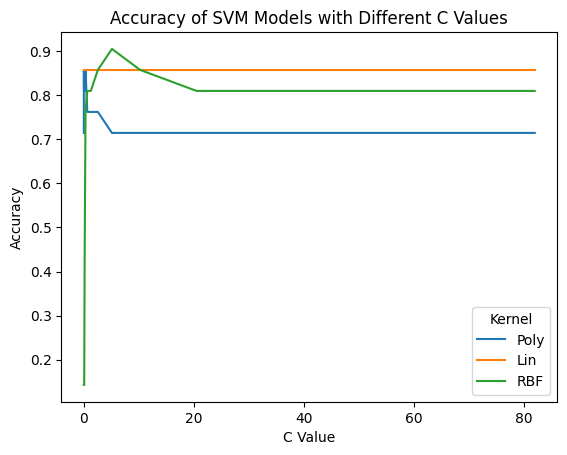

In [202]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=combined_results_df, x=0, y=1, hue='Kernel')
plt.xlabel('C Value')
plt.ylabel('Accuracy')
plt.title('Accuracy of SVM Models with Different C Values')
plt.savefig('SVM_Accuracy_Plot.png')

In [222]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import numpy as np

# Assuming 'TrainDF' is your DataFrame containing the features and 'TrainLabels' contains the labels
X = TrainDF
y = TrainLabels

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit a Linear SVC model
model = LinearSVC()
model.fit(X_scaled, y)

# Get the coefficients and feature names
coefficients = model.coef_[0]
feature_names = X.columns

# Create a DataFrame to hold feature names and their corresponding coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Coefficient': np.abs(coefficients)
})

# Sort the features by absolute coefficient values
top_influential_features = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

# Get the top 2 influential features
top_2_features = top_influential_features.head(2)

print("Top 2 Influential Features:")
print(top_2_features)

Top 2 Influential Features:
         Feature  Coefficient  Absolute Coefficient
6   Wednesday_PM    -0.639486              0.639486
10     Friday_PM    -0.540562              0.540562


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


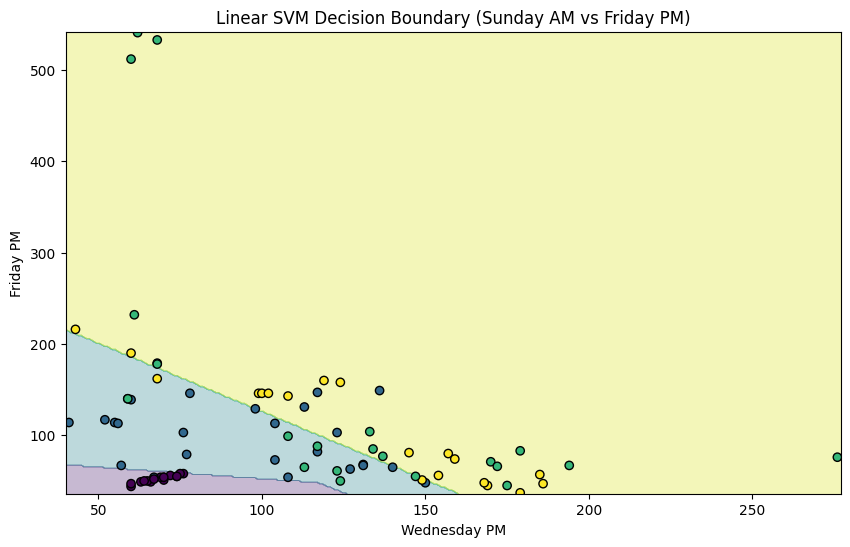

In [223]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# 1. Select ONLY 2 features
# ---------------------------
X = turnip[["Wednesday_PM", "Friday_PM"]]
y = turnip["Label"]

# Encode labels (safe for plotting)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ---------------------------
# 2. Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ---------------------------
# 3. Train Linear SVM
# ---------------------------
model = SVC(kernel="linear", C=1.0)
model.fit(X_train, y_train)

# ---------------------------
# 4. Create mesh grid
# ---------------------------
x_min, x_max = X_train["Wednesday_PM"].min() - 1, X_train["Wednesday_PM"].max() + 1
y_min, y_max = X_train["Friday_PM"].min() - 1, X_train["Friday_PM"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# ---------------------------
# 5. Predict over grid
# ---------------------------
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ---------------------------
# 6. Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# data points
plt.scatter(
    X_train["Wednesday_PM"],
    X_train["Friday_PM"],
    c=y_train,
    edgecolors="k"
)

plt.xlabel("Wednesday PM")
plt.ylabel("Friday PM")
plt.title("Linear SVM Decision Boundary (Wednesday PM vs Friday PM)")

plt.show()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


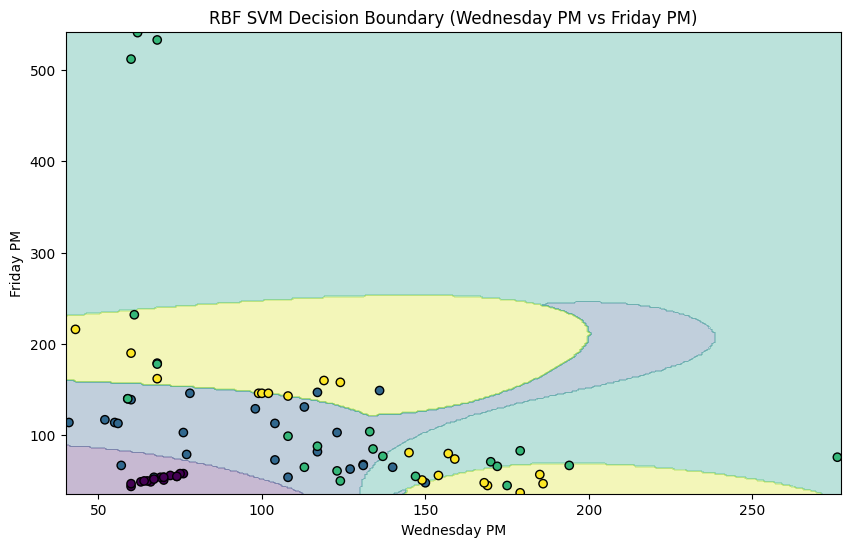

In [224]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# 1. Select ONLY 2 features
# ---------------------------
X = turnip[["Wednesday_PM", "Friday_PM"]]
y = turnip["Label"]

# Encode labels (safe for plotting)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ---------------------------
# 2. Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ---------------------------
# 3. Train Linear SVM
# ---------------------------
model = SVC(kernel="rbf", C=5)
model.fit(X_train, y_train)

# ---------------------------
# 4. Create mesh grid
# ---------------------------
x_min, x_max = X_train["Wednesday_PM"].min() - 1, X_train["Wednesday_PM"].max() + 1
y_min, y_max = X_train["Friday_PM"].min() - 1, X_train["Friday_PM"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# ---------------------------
# 5. Predict over grid
# ---------------------------
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ---------------------------
# 6. Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# data points
plt.scatter(
    X_train["Wednesday_PM"],
    X_train["Friday_PM"],
    c=y_train,
    edgecolors="k"
)

plt.xlabel("Wednesday PM")
plt.ylabel("Friday PM")
plt.title("RBF SVM Decision Boundary (Wednesday PM vs Friday PM)")

plt.show()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


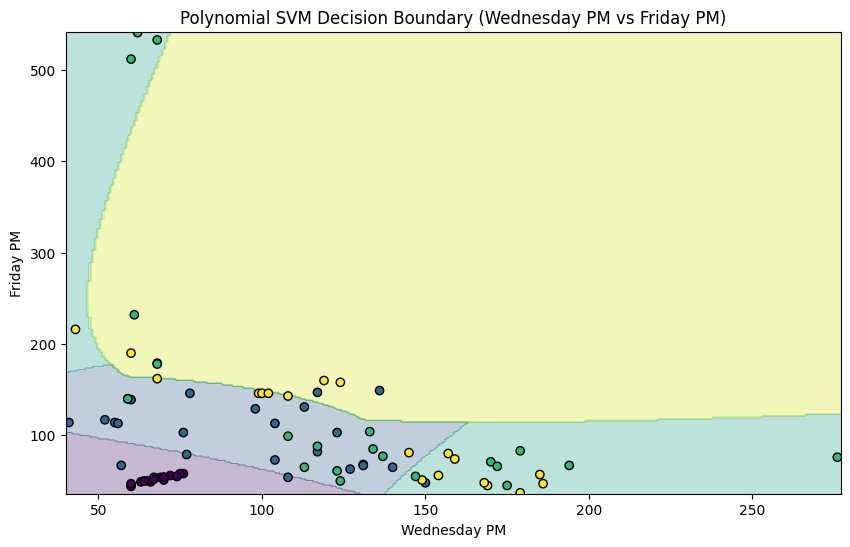

In [226]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# 1. Select ONLY 2 features
# ---------------------------
X = turnip[["Wednesday_PM", "Friday_PM"]]
y = turnip["Label"]

# Encode labels (safe for plotting)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ---------------------------
# 2. Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ---------------------------
# 3. Train Linear SVM
# ---------------------------
model = SVC(kernel="poly", C=0.32)
model.fit(X_train, y_train)

# ---------------------------
# 4. Create mesh grid
# ---------------------------
x_min, x_max = X_train["Wednesday_PM"].min() - 1, X_train["Wednesday_PM"].max() + 1
y_min, y_max = X_train["Friday_PM"].min() - 1, X_train["Friday_PM"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# ---------------------------
# 5. Predict over grid
# ---------------------------
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ---------------------------
# 6. Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# data points
plt.scatter(
    X_train["Wednesday_PM"],
    X_train["Friday_PM"],
    c=y_train,
    edgecolors="k"
)

plt.xlabel("Wednesday PM")
plt.ylabel("Friday PM")
plt.title("Polynomial SVM Decision Boundary (Wednesday PM vs Friday PM)")

plt.show()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


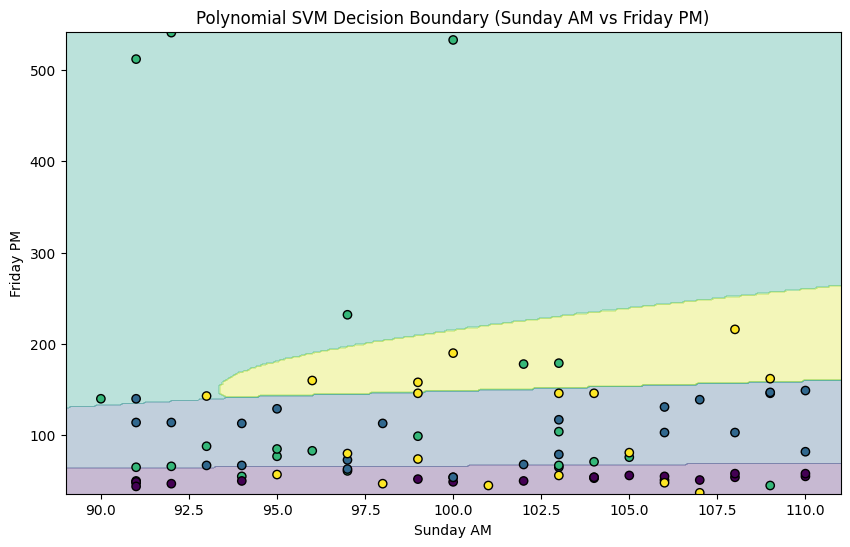

In [207]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# 1. Select ONLY 2 features
# ---------------------------
X = turnip[["Sunday_AM", "Friday_PM"]]
y = turnip["Label"]

# Encode labels (safe for plotting)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ---------------------------
# 2. Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ---------------------------
# 3. Train Polynomial SVM
# ---------------------------
model = SVC(kernel="poly", degree=3, C=1.0, gamma="scale")  # Use polynomial kernel
model.fit(X_train, y_train)

# ---------------------------
# 4. Create mesh grid
# ---------------------------
x_min, x_max = X_train["Sunday_AM"].min() - 1, X_train["Sunday_AM"].max() + 1
y_min, y_max = X_train["Friday_PM"].min() - 1, X_train["Friday_PM"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# ---------------------------
# 5. Predict over grid
# ---------------------------
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ---------------------------
# 6. Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# data points
plt.scatter(
    X_train["Sunday_AM"],
    X_train["Friday_PM"],
    c=y_train,
    edgecolors="k"
)

plt.xlabel("Sunday AM")
plt.ylabel("Friday PM")
plt.title("Polynomial SVM Decision Boundary (Sunday AM vs Friday PM)")

plt.show()